In [ ]:
!pip install Keras-Preprocessing

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.7 MB/s eta 0:00:00


In [ ]:
!pip install Unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.5/235.5 kB 14.1 MB/s eta 0:00:00


In [ ]:
!pip install np_utils

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for np_utils: filename=np_utils-0.6.0-py3-none-any.whl size=56437 sha256=68f732e0949dc7d1af9464f93a1052df6d9ec0c3634909f83d89420def41b4eb
  Stored in directory: /root/.cache/pip/wheels/b6/c7/50/2307607f44366dd021209f660045f8d51cb976514d30be7cc7
Successfully built np_utils


In [ ]:
# LSTM and CNN for sequence classification in the IMDB dataset
import numpy
import tensorflow as tf

from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Conv1D
from keras.layers import MaxPooling1D
from keras.layers import Embedding
from keras.preprocessing import sequence
from tensorflow.keras.preprocessing.text import Tokenizer
#from keras.preprocessing.text import Tokenizer
from keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from tf_data import TF_Data
import pandas
from keras.models import load_model
from os.path import isfile
import os
from keras.optimizers import Adam
import pickle

In [ ]:
# class of input data
# Function to plot class distribution
import matplotlib.pyplot as plt
import seaborn as sns

def plot_class_distribution(df, title):
    sns.countplot(x='ms_today', data=df)
    plt.title(title)
    plt.xlabel('Class')
    plt.ylabel('Frequency')
    plt.xticks([0, 1])
    plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv('FileName2_UTF8.csv')
df.head()

,Unnamed: 0,Headline,Timestamp,result,ms_today,ms_tomorrow,normalized_headline
0,24,Sensex falls ahead of GST; set for first month...,2017-06-30,True,1,0,sensex falls ahead of gst; set for first month...
1,46,"Sensex trades flat, Nifty below 9,500; broader...",2017-06-30,True,1,0,"sensex trades flat, nifty below 9,500; broader..."
2,89,"Sensex trades lower, Nifty below 9,500; BSE Mi...",2017-06-30,True,1,0,"sensex trades lower, nifty below 9,500; bse mi..."
3,90,"Market in wait and watch, Sensex slips over 15...",2017-06-30,True,1,0,"market in wait and watch, sensex slips over 15..."
4,112,"Markets Live: Sensex, Nifty fall steeply ahead...",2017-06-30,True,1,0,"markets live: sensex, nifty fall steeply ahead..."


In [ ]:
df = df.sort_values(by="ms_today", ascending = True)

In [ ]:
df.head()

,Unnamed: 0,Headline,Timestamp,result,ms_today,ms_tomorrow,normalized_headline
12016,209433,"Live: Sensex Struggles; ICICI Bank, Wipro Drag",2015-07-24,True,0,0,"live: sensex struggles; icici bank, wipro drag"
12002,209364,Sensex falls nearly 1 percent; ICICI Bank slumps,2015-07-24,True,0,0,sensex falls nearly 1 percent; icici bank slumps
12003,209366,"Sensex fell nearly 1% to 28,112.31 points; ICI...",2015-07-24,True,0,0,"sensex fell nearly 1 to 28,112.31 points; icic..."
12004,209369,"Sensex Falls 258 Points, ICICI Bank Slumps 4%",2015-07-24,True,0,0,"sensex falls 258 points, icici bank slumps 4"
12005,209374,"Sensex Falls 258 Points, ICICI Bank Slumps 4%",2015-07-24,True,0,0,"sensex falls 258 points, icici bank slumps 4"


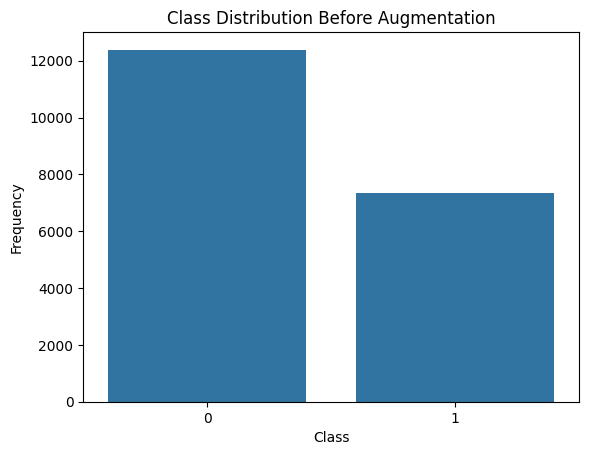

In [ ]:
plot_class_distribution(df, "Class Distribution Before Augmentation")

In [ ]:
def train(filename, model_name, day='tomorrow'):
    # Define the function for training
    reduceLR = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1, mode='auto')
    checkpoint = ModelCheckpoint(model_name, monitor='val_accuracy', mode='auto', verbose=1, save_best_only=True)
    earlyStopping = EarlyStopping(monitor='val_accuracy', min_delta=0, patience=5, verbose=1)

    # Load data from csv
    df = pandas.read_csv(filename)
    headlines = df['normalized_headline']
    top_words = 2000
    max_review_length = 100

    # Create data class
    data = TF_Data(filename, top_words=top_words)
    data.all_x = sequence.pad_sequences(data.all_x, maxlen=max_review_length, padding = "post", truncating="post")   # padding and truncating data within 100

    pickle.dump(data, open(filename.replace(".csv", ".p"), "wb"))
    # Load the dataset but only keep the top n words, zero the rest
    (X_train, y_train), (X_test, y_test) = data.load_data(day=day)
    print(X_train.shape)

    # truncate and pad input sequences
    # X_train = sequence.pad_sequences(X_train, maxlen=max_review_length)
    # X_test = sequence.pad_sequences(X_test, maxlen=max_review_length)
    # create the model
    embedding_vecor_length = 32   # embedding vector size. it's the dimension of outputs
    model = Sequential()
    model.add(Embedding(top_words, embedding_vecor_length, input_length=max_review_length))
    model.add(Conv1D(filters=32, kernel_size=3, padding='same', activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(LSTM(100))
    model.add(Dense(1, activation='sigmoid'))
    optimizer = Adam(learning_rate=1e-3)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    if isfile(model_name) and False:
        print('Checkpoint Loaded')
        model = save_model(model_name)
    print(model.summary())

    model.fit(X_train, y_train, validation_split=0.02, epochs=100, batch_size=64,
              callbacks=[checkpoint,reduceLR, earlyStopping])
    # Final evaluation of the model
    model = load_model(model_name)
    scores = model.evaluate(X_test, y_test, verbose=0)
    fd = open('accuracy.csv', 'a')
    CsvRow = [filename, day, "Accuracy: %.2f%%" % (scores[1] * 100)]
    print(CsvRow)
    fd.write(", ".join(CsvRow) + "\n")
    fd.close()


for f in os.listdir(r"./data"):
    if (f.endswith('.csv')):
        for d in ['ms_today', 'ms_tomorrow']:
            train(os.path.join(r"./data", f), f.replace(".csv", "_" + d + "_.keras"), d)

(13814, 100)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_6 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_6 (MaxPooling1D)       │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_6 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_7 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_7 (MaxPooling1D)       │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
206/212 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6778 - loss: 0.6251
Epoch 1: val_accuracy improved from -inf to 0.67870, saving model to FileName2_UTF8_ms_tomorrow_.keras
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6783 - loss: 0.6249 - val_accuracy: 0.6787 - val_loss: 0.6279 - learning_rate: 0.0010
Epoch 2/100
210/212 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6947 - loss: 0.6176
Epoch 2: val_accuracy did not improve from 0.67870
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6947 - loss: 0.6176 - val_accuracy: 0.6787 - val_loss: 0.6292 - learning_rate: 0.0010
Epoch 3/100
211/212 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6890 - loss: 0.6204
Epoch 3: val_accuracy did not improve from 0.67870
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6891 - loss: 0.6204 - val_accuracy: 0.6787 - val_loss: 0.6284 - learning_rate: 0.0010
Epoch 4/100
206/212 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6932 - loss: 0.6179
Epoch 4: val_accura

In [ ]:
# Modify the values of parameters of reduceLR, checkpoint, earlyStopping to stop at epoch 15~16 as desciption of Gite's paper
def train(filename, model_name, day='tomorrow'):
    # Create an instance of the function for training
    reduceLR = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1, mode='min')
    checkpoint = ModelCheckpoint(model_name, monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)
    earlyStopping = EarlyStopping(monitor='val_accuracy', mode='max', min_delta=0, patience=15, verbose=1)

    # Load data from csv
    df = pandas.read_csv(filename)
    headlines = df['normalized_headline']
    top_words = 2000
    max_review_length = 100

    # Create data class
    data = TF_Data(filename, top_words=top_words)
    data.all_x = sequence.pad_sequences(data.all_x, maxlen=max_review_length, padding = "post", truncating="post")   # padding and truncating data within 100

    pickle.dump(data, open(filename.replace(".csv", ".p"), "wb"))
    # Load the dataset but only keep the top n words, zero the rest
    (X_train, y_train), (X_test, y_test) = data.load_data(day=day)
    print(X_train.shape)

    # create the model
    embedding_vecor_length = 32   # embedding vector size. it's the dimension of outputs
    model = Sequential()
    model.add(Embedding(top_words, embedding_vecor_length, input_length=max_review_length))
    model.add(Conv1D(filters=32, kernel_size=3, padding='same', activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(LSTM(100))
    model.add(Dense(1, activation='sigmoid'))
    optimizer = Adam(learning_rate=1e-3)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    if isfile(model_name) and False:
        print('Checkpoint Loaded')
        model = save_model(model_name)
    print(model.summary())

    model.fit(X_train, y_train, epochs=100, batch_size=64, validation_data=(X_test, y_test),
              callbacks=[checkpoint,reduceLR, earlyStopping])
    # Final evaluation of the model
    model = load_model(model_name)
    scores = model.evaluate(X_test, y_test, verbose=0)
    fd = open('accuracy.csv', 'a')
    CsvRow = [filename, day, "Accuracy: %.2f%%" % (scores[1] * 100)]
    print(CsvRow)
    fd.write(", ".join(CsvRow) + "\n")
    fd.close()


for f in os.listdir(r"./data"):
    if (f.endswith('.csv')):
        for d in ['ms_today', 'ms_tomorrow']:
            train(os.path.join(r"./data", f), f.replace(".csv", "_" + d + "_.keras"), d)

(13814, 100)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_8 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_8 (MaxPooling1D)       │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_8 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_9 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_9 (MaxPooling1D)       │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_9 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6769 - loss: 0.6276
Epoch 1: val_accuracy improved from -inf to 0.68970, saving model to FileName2_UTF8_ms_tomorrow_.keras
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6769 - loss: 0.6275 - val_accuracy: 0.6897 - val_loss: 0.6193 - learning_rate: 0.0010
Epoch 2/100
215/216 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6909 - loss: 0.6196
Epoch 2: val_accuracy did not improve from 0.68970
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6909 - loss: 0.6196 - val_accuracy: 0.6897 - val_loss: 0.6268 - learning_rate: 0.0010
Epoch 3/100
212/216 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6963 - loss: 0.6158
Epoch 3: val_accuracy did not improve from 0.68970
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6962 - loss: 0.6158 - val_accuracy: 0.6897 - val_loss: 0.6194 - learning_rate: 0.0010
Epoch 4/100
211/216 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6913 - loss: 0.6183
Epoch 4: val_accur

In [ ]:
# Up sampling due to the calculation of evaluation metrics of the above results is strange.
# Excepting accuracy, other metrics such as precision, recall and F1-score were 0.
!pip install pandas scikit-learn nlpaug

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 24.9 MB/s eta 0:00:00


In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
# Data Augmentation
import nlpaug.augmenter.word as naw

def synonym_augmentation(text, augmenter, num_aug=1):
    augmented_texts = []
    for _ in range(num_aug):
        augmented_text = str(augmenter.augment(text)).replace("[", "")
        augmented_text = augmented_text.replace("]", "")
        augmented_texts.append(augmented_text)
    return augmented_texts

def augment_dataset(df_origin):

    # Initialize the synonym augmenter
    synonym_aug = naw.SynonymAug(aug_src='wordnet')  # Based wordnet

    # Apply augmentation to minority class
    minority_df1 = df_origin[df_origin['ms_today'] == 1]
    augmented_positive = []
    augmented_date = []
    augmented_ms_tomorrow = []
    augmented_result = []
    augmented_headline = []
    augmented_ms_today = []

    i = 0
    for text in minority_df1['normalized_headline']:
        augmented = synonym_augmentation(text, synonym_aug, num_aug=1)
        augmented_positive.extend(augmented)
        augmented_date.extend([minority_df1.iloc[i]['Timestamp']])
        #augmented_ms_tomorrow.extend([minority_df1.iloc[i]['ms_tomorrow']])
        augmented_ms_today.extend([minority_df1.iloc[i]['ms_today']])
        augmented_result = ["TRUE"] * len(augmented_positive)
        augmented_headline.extend([minority_df1.iloc[i]['Headline']])

        i += 1

    # Create augmented DataFrame for ms_tomorrow
    augmented_df1 = pd.DataFrame({
        'normalized_headline': augmented_positive,
        'ms_today': augmented_ms_today,
        'Timestamp' : augmented_date,
        'ms_tomorrow' : 1,
        'result' : augmented_result,
        'Headline' : augmented_headline
    })

    # Combine original and augmented data
    df_augmented = pd.concat([df_origin, augmented_df1]).reset_index(drop=True)
    return df_augmented

In [ ]:
# Do augment on train set
df = augment_dataset(df)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


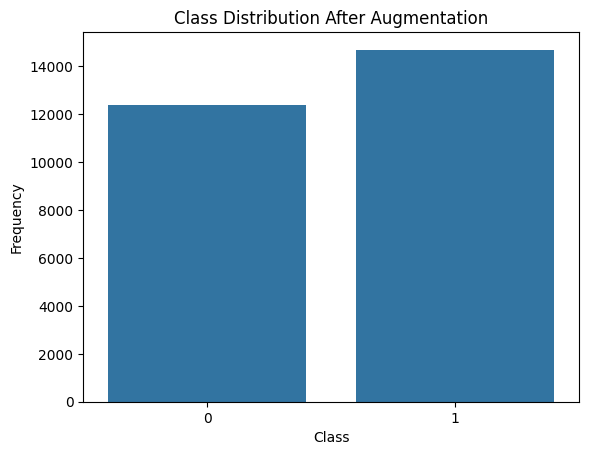

In [ ]:
plot_class_distribution(df, "Class Distribution After Augmentation")

In [ ]:
combined_df.to_csv("FileName2_UTF8_Augmented.csv")

In [ ]:
def train(filename, model_name, day='tomorrow'):
    # Define the function for training
    reduceLR = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1, mode='min')
    checkpoint = ModelCheckpoint(model_name, monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)
    earlyStopping = EarlyStopping(monitor='val_accuracy', mode='max', min_delta=0, patience=15, verbose=1)

    # Load data from csv
    df = pandas.read_csv(filename)
    headlines = df['normalized_headline']
    top_words = 2000
    max_review_length = 100

    # Create data class
    data = TF_Data(filename, top_words=top_words)
    data.all_x = sequence.pad_sequences(data.all_x, maxlen=max_review_length, padding = "post", truncating="post")   # padding and truncating data within 100

    pickle.dump(data, open(filename.replace(".csv", ".p"), "wb"))
    # Load the dataset but only keep the top n words, zero the rest
    (X_train, y_train), (X_test, y_test) = data.load_data(day=day)
    print(X_train.shape)

    # truncate and pad input sequences
    # X_train = sequence.pad_sequences(X_train, maxlen=max_review_length)
    # X_test = sequence.pad_sequences(X_test, maxlen=max_review_length)
    # create the model
    embedding_vecor_length = 32   # embedding vector size. it's the dimension of outputs
    model = Sequential()
    model.add(Embedding(top_words, embedding_vecor_length, input_length=max_review_length))
    model.add(Conv1D(filters=32, kernel_size=3, padding='same', activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(LSTM(100))
    model.add(Dense(1, activation='sigmoid'))
    optimizer = Adam(learning_rate=1e-3)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    if isfile(model_name) and False:
        print('Checkpoint Loaded')
        model = save_model(model_name)
    print(model.summary())

    model.fit(X_train, y_train, validation_split=0.02, epochs=100, batch_size=64,
              callbacks=[checkpoint,reduceLR, earlyStopping])
    # Final evaluation of the model
    model = load_model(model_name)
    scores = model.evaluate(X_test, y_test, verbose=0)
    fd = open('accuracy.csv', 'a')
    CsvRow = [filename, day, "Accuracy: %.2f%%" % (scores[1] * 100)]
    print(CsvRow)
    fd.write(", ".join(CsvRow) + "\n")
    fd.close()


for f in os.listdir(r"./data"):
    if (f.endswith('.csv')):
        for d in ['ms_today', 'ms_tomorrow']:
            train(os.path.join(r"./data", f), f.replace(".csv", "_" + d + "_.keras"), d)

(18957, 100)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4992 - loss: 0.6934
Epoch 1: val_accuracy improved from -inf to 0.50789, saving model to FileName2_UTF8_Augmented_ms_tomorrow_.keras
291/291 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4992 - loss: 0.6934 - val_accuracy: 0.5079 - val_loss: 0.6930 - learning_rate: 0.0010
Epoch 2/100
289/291 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5100 - loss: 0.6929
Epoch 2: val_accuracy did not improve from 0.50789
291/291 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5099 - loss: 0.6929 - val_accuracy: 0.5079 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 3/100
289/291 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5128 - loss: 0.6907
Epoch 3: val_accuracy improved from 0.50789 to 0.63158, saving model to FileName2_UTF8_Augmented_ms_tomorrow_.keras
291/291 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5131 - loss: 0.6905 - val_accuracy: 0.6316 - val_loss: 0.5975 - learning_rate: 0.0010
Epoch 4/100
289/291 ━━━━━━━━━━━